# Deep Learning
## Actividad 1: Deep Vision

Joaquin Perticari

Jordi Servat

Christian Méndez


# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

Recomendaciones en el Uso de Colab:

- Eliminar las variables innecesarias para liberar RAM mediante la sentencia:

In [ ]:
del nombrevariable

IMPORTACIÓN DE LIBRERÍAS

In [2]:
pip install tensorflow

  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
INFO: pip is looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 MB 6.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 12.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 10.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 7.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 36.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 36.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Import the necessary packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tarfile
import pickle
import random
%matplotlib inline

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
# from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# Cargamos el dataset de cifar100
from tensorflow.keras.datasets import cifar100

Cargando los datos

In [21]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data(label_mode='fine')

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [13]:
# Función de entrenamiento sin aplicar data augmentation
def train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER, learn_rate=0.0005):
  # Resumen del modelo
  pre_trained_model.summary()

  # Compilar el modelo
  print("[INFO]: Compilando el modelo...")
  pre_trained_model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=learn_rate), metrics=["accuracy"])

  # Entrenamiento de la red
  print("[INFO]: Entrenando la red...")
  H_pre = pre_trained_model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.2) # Destinamos 20% a validación
  # Almaceno el modelo en Drive
  # Almacenamos el modelo empleando la función mdoel.save de Keras
  pre_trained_model.save(BASE_FOLDER+"deepCNN_CALTECH101_pretrained.h5")

  # Evaluación del modelo
  print("[INFO]: Evaluando el modelo...")
  # Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
  predictions = pre_trained_model.predict(x_test, batch_size=128)
  # Sacamos el report para test
  print(classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames))

  # Gráficas
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(np.arange(0, 20), H_pre.history["loss"], label="train_loss")
  plt.plot(np.arange(0, 20), H_pre.history["val_loss"], label="val_loss")
  plt.plot(np.arange(0, 20), H_pre.history["accuracy"], label="train_acc")
  plt.plot(np.arange(0, 20), H_pre.history["val_accuracy"], label="val_acc")
  plt.title("Training Loss and Accuracy")
  plt.xlabel("Epoch #")
  plt.ylabel("Loss/Accuracy")
  plt.legend()
  plt.show()

Inspeccionando los datos

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Número de clases: 100


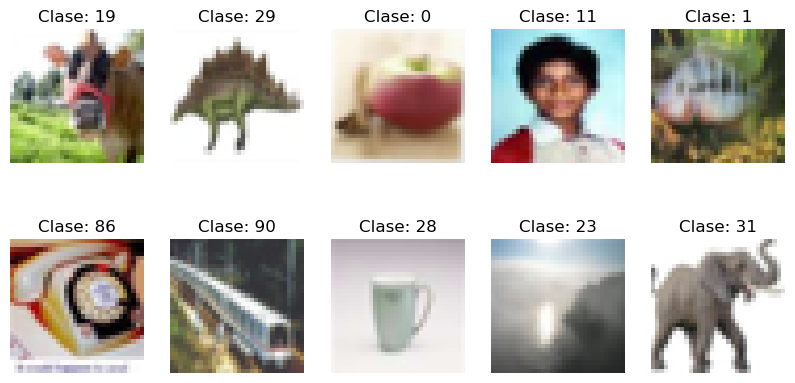

La clase es [31]


In [23]:
# Ver las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


# Número de clases
num_classes = len(np.unique(y_train))
print(f"Número de clases: {num_classes}")

# Mostrar algunas imágenes de ejemplo (opcional)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(f"Clase: {y_train[i][0]}")
    plt.axis('off')
plt.show()
print("La clase es %s" %(y_train[i]))

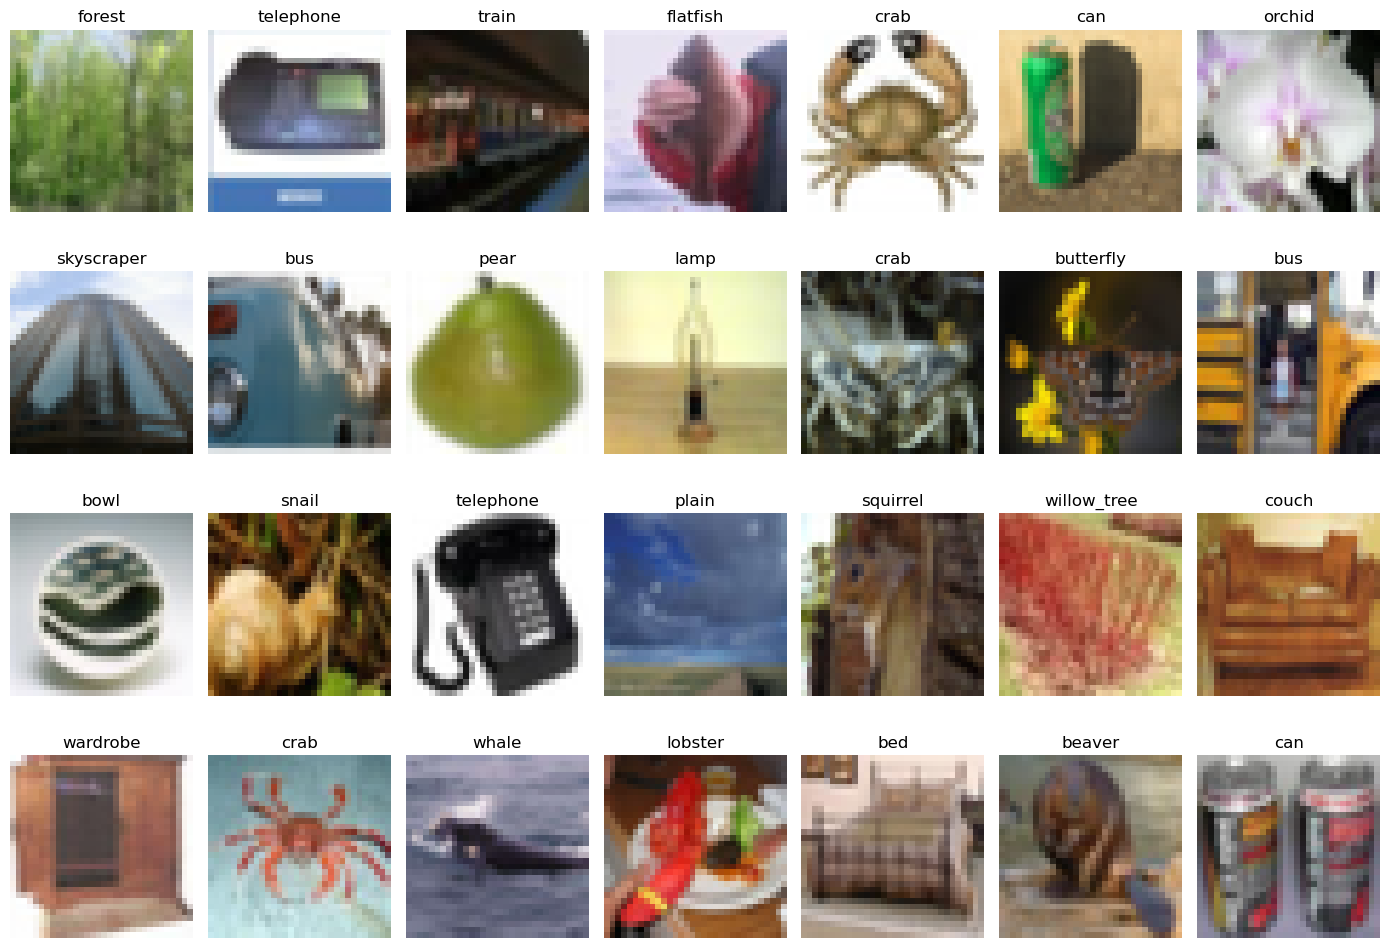

In [25]:
fig = plt.figure(figsize=(14, 10))

# Seleccionar 28 índices aleatorios del conjunto de entrenamiento
indices = random.sample(range(len(x_train)), 28)

for n, i in enumerate(indices):
    fig.add_subplot(4, 7, n + 1)
    img = x_train[i]                # la imagen
    label_idx = y_train[i][0]        # índice de la clase (si y_train tiene forma (N,1))
    class_name = labelNames[label_idx]  # nombre de la clase
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

[Text(0.5, 1.0, 'Número de muestras por clase'),
 Text(0, 0.5, 'Número de muestras')]

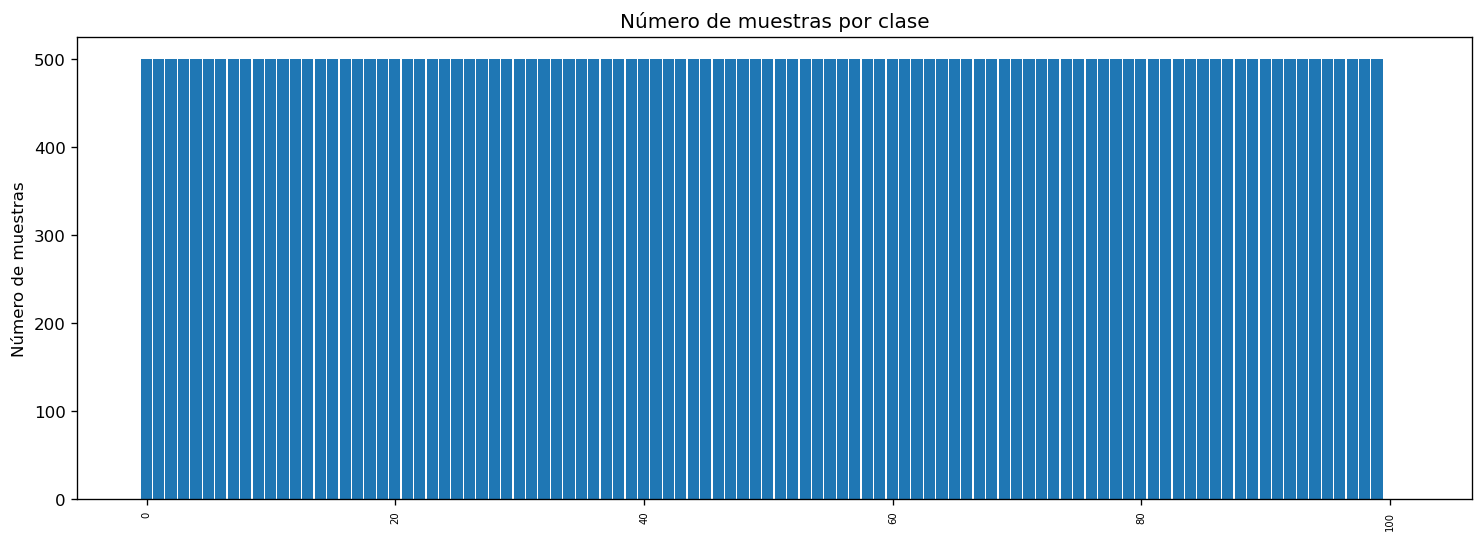

In [27]:
plt.rcParams.update({'figure.figsize':(15,5), 'figure.dpi':120})

# Plot Histogram on x
plt.hist(y_train, bins=range(0,103), width=0.9, align='left')
plt.xticks(rotation = 90, size=6)
plt.gca().set(title='Número de muestras por clase', ylabel='Número de muestras')

In [48]:
# Visualizamos todas las muestras de una clase en particular
clase = "14"
idx_clase = labelNames.index(clase)  # 26

# Seleccionar todas las imágenes de esa clase
imagenes_clase = x_train[y_train.flatten() == idx_clase]

# Mostrar las primeras 9
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(imagenes_clase[i])
    plt.title(f"{clase} {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [52]:
print(y_train.max())

99


In [39]:
labelNames = np.unique(y_train)
print("Las %d clases son: " %(len(labelNames)))
print(labelNames)

Las 100 clases son: 
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


Para obtener la solución final, se siguen los siguientes pasos:

  1. En primer lugar, se obtienen los resultados tras aplicar TRANSFER LEARNING con la red MobileNetV2
  2. Se aplicará FINE TUNING
  3. Se valorará modificar la estructura del TOP MODEL (capas convolucionales y número de neuronas)
  4. Se valorarán distintas técnicas de regularización (weight regularization, dropout y batch normalization)
  5. Se aplicará DATA AUGMENTATION


En primer lugar, utilizaremos la red MobileNetV2

**Acondicionando el conjunto de datos para la red MobileNetV2**

In [28]:
from tensorflow.keras.applications.mobilenet import preprocess_input

# Los datos están normalizados y preprocess_input requiere un rango [0, 255]
# Multiplicamos *255
x_train, x_test = x_train * 255.0, x_test * 255.0

# Se normalizan los datos como se normalizaron en el entrenamiento de ImageNet con la red MobileNetV2
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

# Keras tiene una función para pasar directamente los datos en [0,1] o en [0,255]
# x_train = preprocess_input(x_train)

#### **Cargando la topología de CNN (base model)**

In [31]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet',
                 include_top=False,
                 input_shape=(32,32,3))
base_model.summary()

9406464/9406464 [==============================] - 0s 0us/step
Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 16, 16, 32)           864       ['input_2[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 16, 16, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReL

#### **Creando el top model y congelando TODAS las capas convolucionales (TRANSFER LEARNING) + Entrenamiento**

In [53]:
BASE_FOLDER = './resultados'
os.makedirs(BASE_FOLDER, exist_ok=True)

In [59]:
print("Tipo de y_train:", type(y_train))
print("Shape de y_train:", y_train.shape)
print("Primeros 5 valores:", y_train[:5])

Tipo de y_train: <class 'numpy.ndarray'>
Shape de y_train: (50000,)
Primeros 5 valores: [19 29  0 11  1]


In [ ]:
# Compilar el modelo (¡importante!)
pre_trained_model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

# Entrenar directamente con .fit()
history = pre_trained_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test)   # opcional, pero recomendado
)

# (Opcional) Guardar el historial para visualizarlo después
import pickle
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/20
391/391 [==============================] - 37s 85ms/step - loss: 4.4874 - accuracy: 0.0282 - val_loss: 4.4302 - val_accuracy: 0.0381
Epoch 2/20
391/391 [==============================] - 32s 81ms/step - loss: 4.3837 - accuracy: 0.0411 - val_loss: 4.3971 - val_accuracy: 0.0366
Epoch 3/20
391/391 [==============================] - 32s 81ms/step - loss: 4.3421 - accuracy: 0.0459 - val_loss: 4.3843 - val_accuracy: 0.0427
Epoch 4/20
391/391 [==============================] - 33s 84ms/step - loss: 4.3137 - accuracy: 0.0495 - val_loss: 4.3718 - val_accuracy: 0.0431
Epoch 5/20
391/391 [==============================] - 32s 83ms/step - loss: 4.2892 - accuracy: 0.0531 - val_loss: 4.3656 - val_accuracy: 0.0443
Epoch 6/20
391/391 [==============================] - 35s 89ms/step - loss: 4.2675 - accuracy: 0.0558 - val_loss: 4.3630 - val_accuracy: 0.0433
Epoch 7/20
391/391 [==============================] - 33s 83ms/step - loss: 4.2467 - accuracy: 0.0596 - val_loss: 4.3625 - val_accuracy:

In [58]:
# conectarlo a nueva parte densa
base_model.trainable = False # Evitar que los pesos se modifiquen en la parte convolucional -> TRANSFER LEARNING
pre_trained_model = Sequential()
pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(512, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))
pre_trained_model.summary()

# Entrenando la solución
train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 1, 1, 1280)        2257984   
 tional)                                                         
                                                                 
 flatten_3 (Flatten)         (None, 1280)              0         
                                                                 
 dense_6 (Dense)             (None, 512)               655872    
                                                                 
 dense_7 (Dense)             (None, 100)               51300     
                                                                 
Total params: 2965156 (11.31 MB)
Trainable params: 707172 (2.70 MB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________
Model: "sequential_3"
________________________________________________________

ValueError: in user code:

    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/site-packages/keras/src/engine/training.py", line 1081, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/site-packages/keras/src/engine/training.py", line 1139, in compute_loss
        return self.compiled_loss(
    File "/opt/anaconda3/envs/pythonProject/lib/python3.8/si

### **Utilizamos la red Xception**